<a href="https://colab.research.google.com/github/hgkim-gnbeng/tunnel_fire_dynamics_book/blob/book_example/%EC%98%88%EC%A0%9C_5_7_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

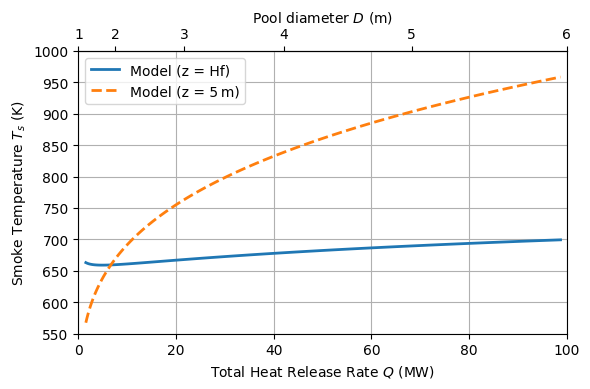

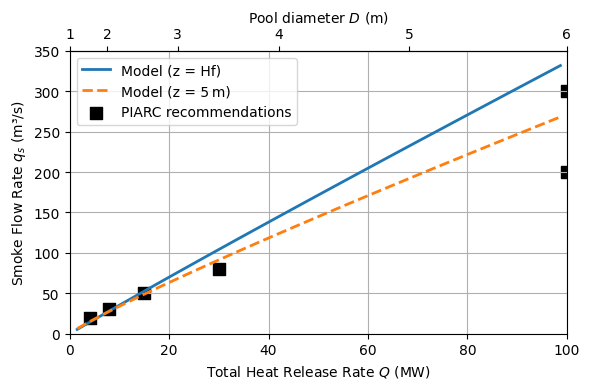

In [3]:
#[예제 5.7.2]

import numpy as np
import matplotlib.pyplot as plt

# 1) 상수 정의
rho0    = 1.2           # kg/m3, 대기 밀도
R_sp    = 287.0         # J/(kg·K), 기체상수
DeltaHc = 44.9e6        # J/kg, 헵탄 순발열
g       = 9.81          # m/s2, 중력가속도
v_m     = 24.461e-3     # m3/mol, 기체 몰부피 (STP)
sum_ai  = 56.36         # mol gas per mol fuel
M_fuel  = 0.100         # kg/mol, 헵탄

# 2) Megret 경험식 구현
def burning_rate(D):
    """Eq 1.13: m'' [kg/m2/s]"""
    return 0.0784 * (1 - np.exp(-0.8 * D))

def flame_height(D, mpp):
    """Eq 1.15: Hf = 42·D·(m''/(ρ0·√(gD)))^0.61"""
    return 42 * D * (mpp / (rho0 * np.sqrt(g * D)))**0.61

def entrainment_ratio(z, R):
    """Eq 1.14: n = 11·(2.13·(z/R)^0.53 – 1)"""
    return 11 * (2.13 * (z / R)**0.53 - 1)

def smoke_temperature(n):
    """Eq 1.12: (30.7+2.0n)·1e-3 Ts² + (407.0+32.7n)·Ts – (8.77e5+9.9e3n)=0"""
    A = (30.7 + 2.0 * n) * 1e-3
    B =  (407.0 + 32.7 * n)
    C = -(8.77e5 + 9.9e3 * n)
    roots = np.roots([A, B, C])
    return roots[roots>0].min()

def compute_smoke_flow(D, z):
    """
    D: pool diameter [m]
    z: evaluation height [m] (e.g. Hf or 5.0)
    returns: Q [MW], Vs [m3/s], Ts [K]
    """
    # 2.1 단위면적 연소율 & 총 연소량
    mpp   = burning_rate(D)         # kg/m2/s
    S     = np.pi * D**2 / 4        # m2
    mdot  = mpp * S                 # kg/s

    # 2.2 전체 HRR (Eq 1.4)
    Q  = mdot * DeltaHc / 1e6       # MW

    # 2.3 공기 유입비 (Eq 1.14)
    n  = entrainment_ratio(z, D/2)

    # 2.4 표준 조건 연기 부피유량 (Eq 1.8: (13.8+1.2n)·mdot)
    V0 = (13.8 + 1.2 * n) * mdot     # m3/s

    # 2.5 연기 온도 (Eq 1.12) 및 밀도
    Ts   = smoke_temperature(n)
    rho_s = 101325 / (R_sp * Ts)    # kg/m3

    # 2.6 실제 연기 부피유량 (Eq 1.9)
    Vs   = (rho0 / rho_s) * V0      # m3/s

    return Q, Vs, Ts

# 3) 모델 계산: D=1–6 m
D_vals = np.linspace(1, 6, 100)
Q_hf, Vs_hf, Ts_hf = [], [], []
Q_5m, Vs_5m, Ts_5m = [], [], []


for D in D_vals:
    mpp = burning_rate(D)
    Hf  = flame_height(D, mpp)
    q1, vs1, ts1 = compute_smoke_flow(D, Hf)
    q2, vs2, ts2 = compute_smoke_flow(D, 5.0)

    Q_hf.append(q1); Vs_hf.append(vs1); Ts_hf.append(ts1)
    Q_5m.append(q2); Vs_5m.append(vs2); Ts_5m.append(ts2)


Q_hf  = np.array(Q_hf);  Q_5m  = np.array(Q_5m)
Vs_hf = np.array(Vs_hf); Vs_5m = np.array(Vs_5m)
Ts_hf = np.array(Ts_hf); Ts_5m = np.array(Ts_5m)

# 4) PIARC 추천치 (Table 1)
PIARC_Q  = np.array([4, 8, 15, 30, 100, 100])
PIARC_Vs = np.array([20, 30, 50, 80, 200, 300])

# === Fig.2: Smoke Temperature vs HRR ===
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(Q_hf, Ts_hf,  '-', lw=2, label='Model (z = Hf)')
ax.plot(Q_5m, Ts_5m, '--', lw=2, label='Model (z = 5 m)')

ax.set_xlim(0,100)
ax.set_ylim(550,1000)
ax.set_xlabel('Total Heat Release Rate $Q$ (MW)')
ax.set_ylabel('Smoke Temperature $T_s$ (K)')
ax.grid(True); ax.legend()

# 상단 x축: Pool diameter D
secax = ax.secondary_xaxis(
    'top',
    functions=(lambda Q: np.interp(Q, Q_hf, D_vals),
               lambda D: np.interp(D, D_vals, Q_hf))
)
secax.set_xlabel('Pool diameter $D$ (m)')
secax.set_xticks(np.arange(1,7))

plt.tight_layout()
plt.show()

# === Fig.3: Smoke Flow Rate vs HRR ===
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(Q_hf, Vs_hf,  '-', lw=2, label='Model (z = Hf)')
ax.plot(Q_5m, Vs_5m, '--', lw=2, label='Model (z = 5 m)')

ax.scatter(PIARC_Q, PIARC_Vs, s=80, marker='s', color='k',
           label='PIARC recommendations')
ax.set_xlim(0,100); ax.set_ylim(0,350)
ax.set_xlabel('Total Heat Release Rate $Q$ (MW)')
ax.set_ylabel('Smoke Flow Rate $q_s$ (m³/s)')
ax.grid(True); ax.legend()

# 상단 x축
secax = ax.secondary_xaxis(
    'top',
    functions=(lambda Q: np.interp(Q, Q_hf, D_vals),
               lambda D: np.interp(D, D_vals, Q_hf))
)
secax.set_xlabel('Pool diameter $D$ (m)')
secax.set_xticks(np.arange(1,7))

plt.tight_layout()
plt.show()